In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cell 2 — Load original unscaled data and clustered data
df_original = pd.read_csv("../data/processed/cc_segmentation_raw.csv")
df_clustered = pd.read_csv("../data/processed/cc_segmentation_clustered.csv")

# Add cluster labels to original data
df_original["Cluster"] = df_clustered["Cluster"]
print("Shape:", df_original.shape)

Shape: (8950, 18)


In [3]:
# Cell 3 — Cluster profiles (mean of each feature per cluster)
cluster_profiles = df_original.groupby("Cluster").mean().round(2)
cluster_profiles.T

Cluster,0.0,1.0,2.0,3.0
BALANCE,3372.16,1033.27,2235.74,914.44
BALANCE_FREQUENCY,0.93,0.82,0.94,0.89
PURCHASES,478.68,492.61,3627.10,777.90
ONEOFF_PURCHASES,274.90,298.43,2408.47,330.24
INSTALLMENTS_PURCHASES,204.54,194.34,1218.75,447.97
CASH_ADVANCE,2898.08,601.33,700.12,497.72
PURCHASES_FREQUENCY,0.34,0.32,0.81,0.67
ONEOFF_PURCHASES_FREQUENCY,0.13,0.12,0.56,0.18
PURCHASES_INSTALLMENTS_FREQUENCY,0.23,0.21,0.61,0.53
CASH_ADVANCE_FREQUENCY,0.33,0.11,0.09,0.09


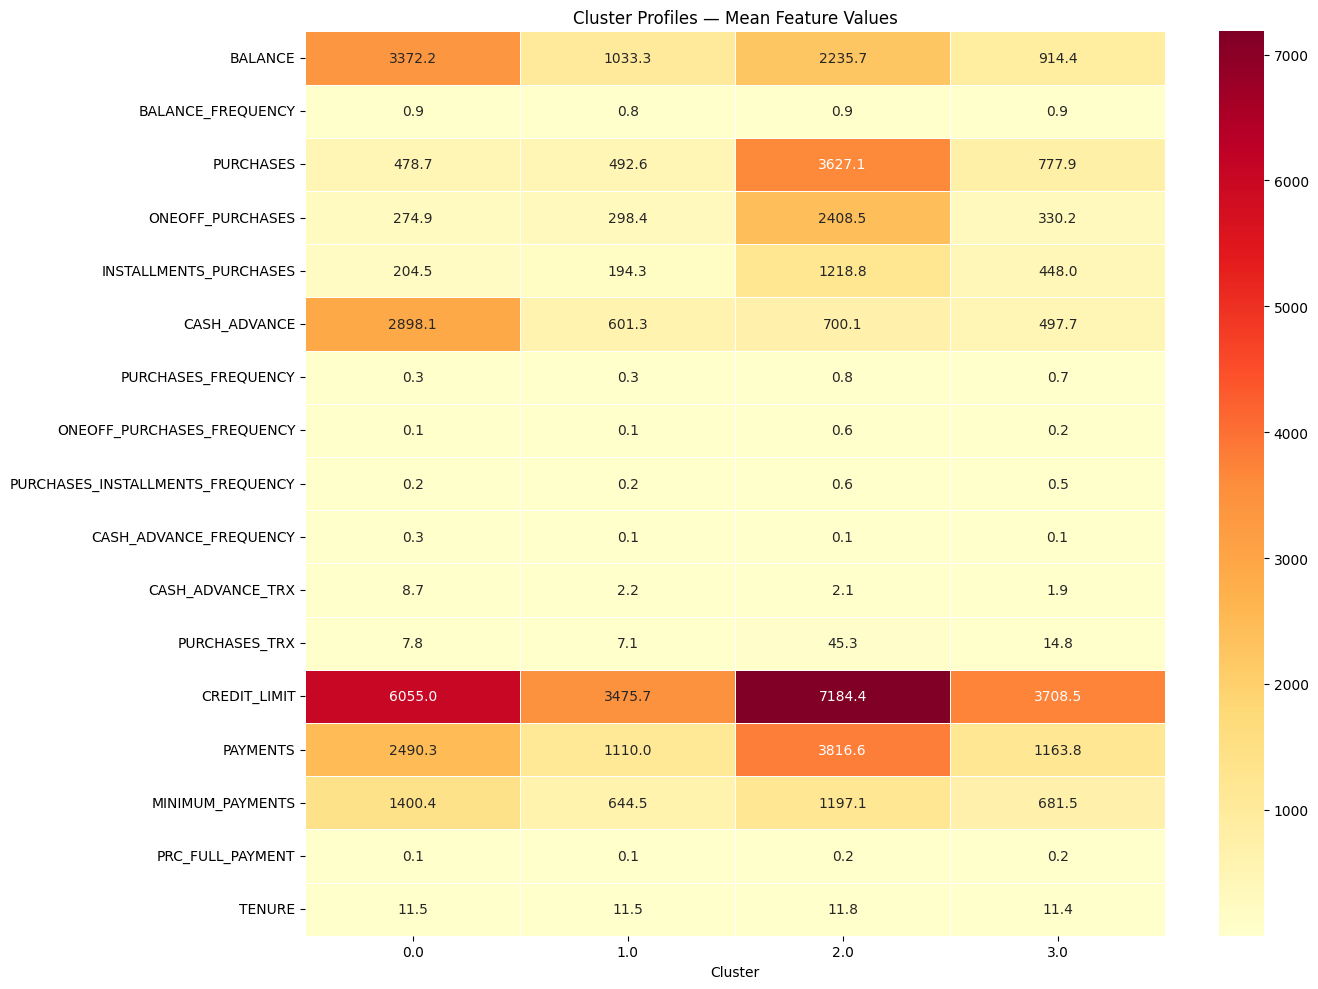

In [4]:
# Cell 4 — Heatmap of cluster profiles
plt.figure(figsize=(14, 10))
sns.heatmap(cluster_profiles.T, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Cluster Profiles — Mean Feature Values")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

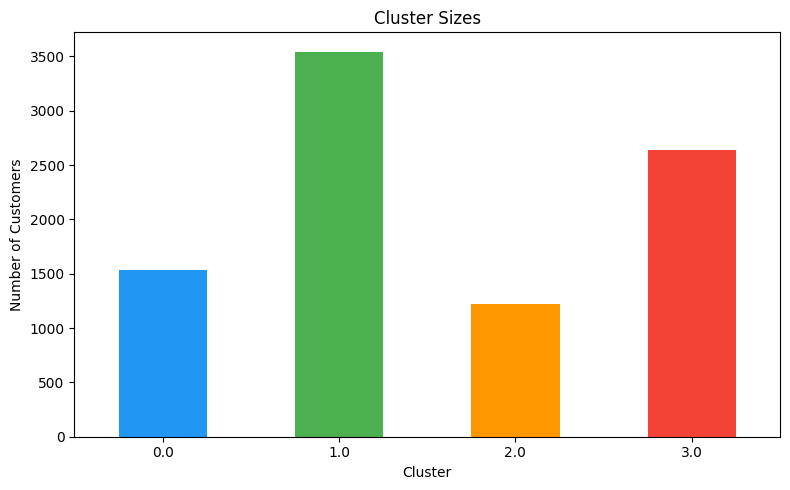

In [5]:
# Cell 5 — Cluster sizes
cluster_sizes = df_original["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_sizes.plot(kind="bar", color=["#2196F3", "#4CAF50", "#FF9800", "#F44336"])
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

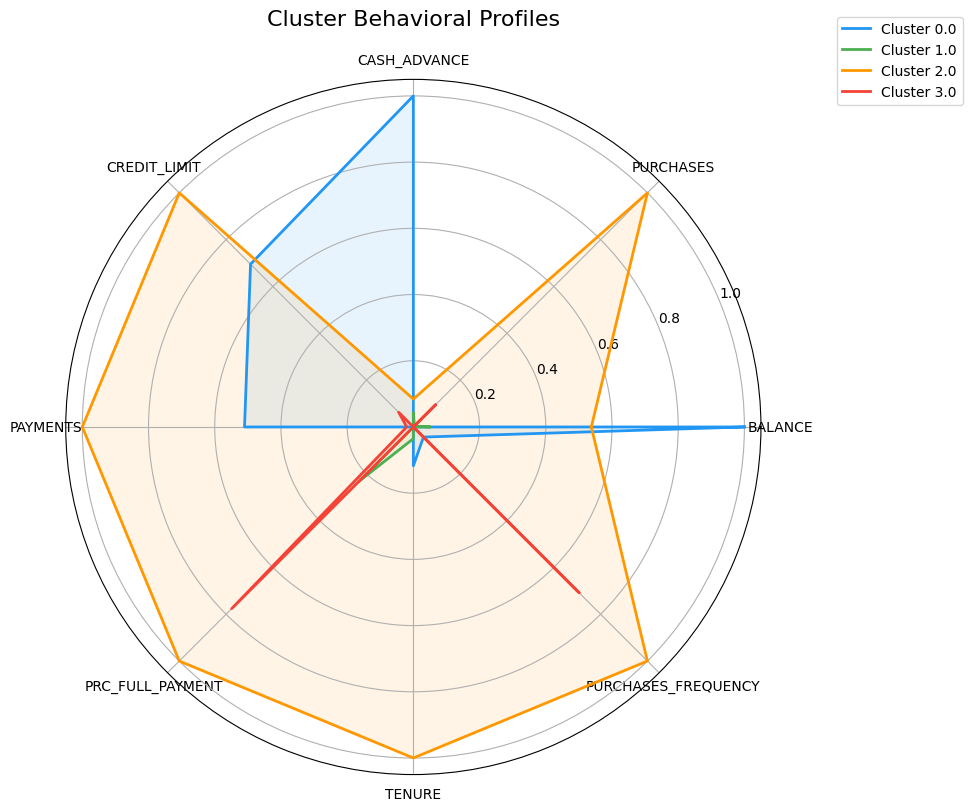

In [7]:
# Cell 6 — Radar chart for cluster comparison
features_to_plot = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
    "PAYMENTS", "PRC_FULL_PAYMENT", "TENURE", "PURCHASES_FREQUENCY"
]

cluster_means = df_original.groupby("Cluster")[features_to_plot].mean()
cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles = np.linspace(0, 2 * np.pi, len(features_to_plot), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

for idx, (i, row) in enumerate(cluster_means_normalized.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=f"Cluster {i}")
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), features_to_plot)
ax.set_title("Cluster Behavioral Profiles", size=16, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## Cluster Business Profiles

| Cluster | Label | Business Action |
|---------|-------|-----------------|
| 0 | Cash-Dependent / High Risk | Enhanced credit scoring, risk monitoring, require guarantees |
| 1 | Dormant / Low Engagement | Activation offers, spend bonuses, retail partnerships |
| 2 | VIP / High Value | Premium tier, loyalty rewards, higher credit limits, personalized deals |
| 3 | Installment Buyers | Flexible installment plans, attractive monthly rates, credit line increases |